## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [14]:
import pandas as pd
import numpy as np
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle
import gc

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../Modules")
sys.path.insert(0, "../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

<rpy2.rinterface_lib.sexp.NULLType object at 0x0000017ADD1D2E90> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Peloponnese'

In [4]:
years = range(2009, 2024)

In [5]:
timelines = []

for year in years:
    df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)
    print(f'Year: {year} | {df.shape}')
    timelines.append(df)

Year: 2009 | (1301225, 44)
Year: 2010 | (1301225, 44)
Year: 2011 | (1301225, 44)
Year: 2012 | (1304790, 44)
Year: 2013 | (1301225, 44)
Year: 2014 | (1301225, 44)
Year: 2015 | (1301225, 44)
Year: 2016 | (1304790, 44)
Year: 2017 | (1301225, 44)
Year: 2018 | (1301225, 44)
Year: 2019 | (1301225, 44)
Year: 2020 | (1304790, 44)


C:\Users\dimit\AppData\Local\Temp\ipykernel_3248\1765925443.py:4: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_{year}_filled.csv', encoding=enc)


Year: 2021 | (1301225, 44)
Year: 2022 | (1301225, 44)
Year: 2023 | (1301225, 44)


In [6]:
# timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_GRID_2016-2018_filled.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS0}_WNV_cases_GRID_2010-2021.csv', encoding=enc)

timeline_file = pd.concat(timelines, ignore_index=True, axis = 0)

In [7]:
del df
del timelines

gc.collect()

0

In [8]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.594940,37.065630,0,2009-01-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
1,21.594940,37.065630,0,2009-01-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
2,21.594940,37.065630,0,2009-01-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
3,21.594940,37.065630,0,2009-01-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
4,21.594940,37.065630,0,2009-01-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1


In [9]:
timeline_file.shape

(19529070, 44)

In [10]:
# wnv_file.head()

In [11]:
# wnv_file.shape

In [12]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except KeyError:
    print ("column not found")

column not found


In [15]:
timeline_file['lst_day'] = timeline_file['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [16]:
timeline_file['lst_day'] = timeline_file['lst_day'].astype(float)

In [17]:
temprature_cols = timeline_file.filter(regex='^lst_*').columns.tolist()

timeline_file[temprature_cols] = timeline_file[temprature_cols].apply(lambda x : x * 0.02 - 273.15)

In [18]:
timeline_file.head()

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,21.594940,37.065630,0,2009-01-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
1,21.594940,37.065630,0,2009-01-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
2,21.594940,37.065630,0,2009-01-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
3,21.594940,37.065630,0,2009-01-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1
4,21.594940,37.065630,0,2009-01-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1


In [19]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [20]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)

timeline_file = encode_cyclical(timeline_file, 'month', 12)

In [21]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

In [22]:
timeline_file

,x,y,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,month_sin,month_cos
0,21.594940,37.065630,0,2009-01-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
1,21.594940,37.065630,0,2009-01-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
2,21.594940,37.065630,0,2009-01-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
3,21.594940,37.065630,0,2009-01-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
4,21.594940,37.065630,0,2009-01-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,2.000000,3,1,NaN,NaN,NaN,NaN,NaN,0.500000,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19529065,23.425140,37.442930,3564,2023-12-27,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,2023,12,0.431798,0.210386,-0.299180,-0.210386,0.385785,0.163078,-0.282021,-0.163078,0.075160,0.039093,0.080285,0.039093,16.050000,10.870000,0.000000,27,13.958387,7.124839,14.003571,5.772857,17.595806,8.142903,21.176000,10.463333,63.394056,134.463440,201.313076,769.861934,3.000000,3,1,13.460000,10.541613,9.888214,12.869355,15.819667,-0.000000,1.000000
19529066,23.425140,37.442930,3564,2023-12-28,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,2023,12,0.431798,0.210386,-0.299180,-0.210386,0.385785,0.163078,-0.282021,-0.163078,0.075160,0.039093,0.080285,0.039093,15.550000,9.370000,0.000000,28,13.958387,7.124839,14.003571,5.772857,17.595806,8.142903,21.176000,10.463333,2.440080,133.372295,198.649787,769.861934,3.000000,3,1,12.460000,10.541613,9.888214,12.869355,15.819667,-0.000000,1.000000
19529067,23.425140,37.442930,3564,2023-12-29,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,2023,12,0.431798,0.210386,-0.299180,-0.210386,0.385785,0.163078,-0.282021,-0.163078,0.075160,0.039093,0.080285,0.039093,16.770000,9.370000,0.000000,29,13.958387,7.124839,14.003571,5.772857,17.595806,8.142903,21.176000,10.463333,0.000000,131.639281,189.095877,769.861934,3.000000,3,1,13.070000,10.541613,9.888214,12.869355,15.819667,-0.000000,1.000000
19529068,23.425140,37.442930,3564,2023-12-30,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,2023,12,0.431798,0.210386,-0.299180,-0.210386,0.385785,0.163078,-0.282021,-0.163078,0.075160,0.039093,0.080285,0.039093,16.770000,9.370000,0.000000,30,13.958387,7.124839,14.003571,5.7

In [23]:
timeline_file.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)
timeline_file['date_string'] = timeline_file['month'].astype(str) + '-' + timeline_file['year'].astype(str)
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['date_string'], format='%m-%Y').dt.to_period('M')
timeline_file.drop(columns=['date_string'], inplace = True)

In [24]:
gc.collect()

0

In [25]:
grouped_by_month = timeline_file.drop(columns=['dt_placement_daily']).groupby(['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME'], as_index = False)

grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

In [26]:
del timeline_file
gc.collect()

0

In [27]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mean[['cell_number','dt_placement','NUTS1_ID','NUTS1_NAME','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME','LAU1_NAME','x','y','MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_min[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_min', 'lst_night': 'lst_night_min'}),
                                     grouped_by_month_max[['lst_day','lst_night']].rename(columns={'lst_day':'lst_day_max', 'lst_night': 'lst_night_max'}),
                                     grouped_by_month_sum[['rainfall']].rename(columns={'rainfall':'rainfall_acc'})], axis=1)

In [28]:
del grouped_by_month
del grouped_by_month_mean
del grouped_by_month_min
del grouped_by_month_max
del grouped_by_month_sum
del grouped_by_month_last

gc.collect()

0

In [29]:
grouped_by_month_dataset.head()

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000


In [30]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst_day_min,lst_night_min,lst_day_max,lst_night_max,rainfall_acc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2.000000,3.000000,1.000000,2009.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641695,3564,2023-08,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3.000000,3.000000,1.000000,2023.000000,8.000000,0.381661,0.004793,-0.329564,-0.004793,0.397382,0.019212,-0.336529,-0.019212,0.028921,0.032760,0.017034,0.032760,35.486296,23.727037,29.606667,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,0.017264,0.535175,0.535175,0.535175,340.472647,28.770000,22.010000,40.490000,27.790000,0.535175
641696,3564,2023-09,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3.000000,3.000000,1.000000,2023.000000,9.000000,0.397427,0.000267,-0.347083,-0.000267,0.403241,0.012661,-0.345614,-0.012661,0.032078,0.037409,0.018026,0.037409,30.214000,22.166000,26.190000,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,3.809299,37.862008,37.862008,41.902286,382.374933,28.930000,22.050000,34.270000,22.630000,41.902286
641697,3564,2023-10,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3.000000,3.000000,1.000000,2023.000000,10.000000,0.439427,0.104942,-0.374480,-0.104942,0.449810,0.121369,-0.375216,-0.121369,0.041670,0.038276,0.030275,0.038276,25.351935,16.879677,21.115806,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,1.236594,37.081316,38.054854,38.334426,

In [31]:
grouped_by_month_dataset['lst_min'] = grouped_by_month_dataset.apply(lambda row: min(row['lst_day_min'], row['lst_night_min']), axis=1)
grouped_by_month_dataset['lst_max'] = grouped_by_month_dataset.apply(lambda row: max(row['lst_day_max'], row['lst_night_max']), axis=1)

In [32]:
grouped_by_month_dataset.drop(columns=['lst_day_min', 'lst_night_min', 'lst_day_max', 'lst_night_max'], inplace=True)

In [33]:
grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']] = grouped_by_month_dataset[['MOUNT_TYPE','URBN_TYPE','COAST_TYPE','year','month']].astype(int)


In [34]:
grouped_by_month_dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641695,3564,2023-08,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,8,0.381661,0.004793,-0.329564,-0.004793,0.397382,0.019212,-0.336529,-0.019212,0.028921,0.032760,0.017034,0.032760,35.486296,23.727037,29.606667,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,0.017264,0.535175,0.535175,0.535175,340.472647,0.535175,22.010000,40.490000
641696,3564,2023-09,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,9,0.397427,0.000267,-0.347083,-0.000267,0.403241,0.012661,-0.345614,-0.012661,0.032078,0.037409,0.018026,0.037409,30.214000,22.166000,26.190000,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,3.809299,37.862008,37.862008,41.902286,382.374933,41.902286,22.050000,34.270000
641697,3564,2023-10,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,10,0.439427,0.104942,-0.374480,-0.104942,0.449810,0.121369,-0.375216,-0.121369,0.041670,0.038276,0.030275,0.038276,25.351935,16.879677,21.115806,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,1.236594,37.081316,38.054854,38.334426,420.709358,38.334426,14.470000,28.590000
641698,3564,2023-11,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,11,0.487211,0.141535,-0.403726,-0.141535,0.469366,0.145710,-0.381396,-0.145710,0.035768,0.030272,0.036136,0.030272,20.771333,13.454667,17.113000,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888

### Add Geomorphological and Land Cover/Use

In [35]:
dataset_locations = grouped_by_month_dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [36]:
dataset_locations_per_year = grouped_by_month_dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [37]:
dataset_locations

,x,y
0,21.594940,37.065630
1,21.594940,37.065630
2,21.594940,37.083600
3,21.594940,37.101570
4,21.594940,37.101570
...,...,...
5817,23.402820,37.424970
5818,23.402820,37.442930
5819,23.425140,37.442930
5820,23.425140,37.442930


In [38]:
dataset_locations_per_year

,x,y,year
0,21.594940,37.065630,2009
1,21.594940,37.065630,2009
2,21.594940,37.065630,2010
3,21.594940,37.065630,2010
4,21.594940,37.065630,2011
...,...,...,...
76042,23.425140,37.442930,2021
76043,23.425140,37.442930,2022
76044,23.425140,37.442930,2022
76045,23.425140,37.442930,2023


In [39]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [40]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 1.5235269231902283e-12


In [41]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_3248\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [42]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.594940,37.065630,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073
1,21.594940,37.065630,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073
2,21.594940,37.083600,1309.623447,1222.832592,2,244.829531,46.089568,185.824431,0.000000,19.829926
3,21.594940,37.101570,1499.125521,405.789559,2,137.481896,43.477309,185.343834,0.000000,3.780454
4,21.594940,37.101570,1499.125521,405.789559,2,137.481896,43.477309,185.343834,0.000000,3.780454
...,...,...,...,...,...,...,...,...,...,...
5817,23.402820,37.424970,1415.166460,119.247323,11,120.225445,119.806926,180.170805,0.000000,8.462383
5818,23.402820,37.442930,3399.206430,1993.562794,16,172.891546,296.490083,178.157643,0.000000,30.999237
5819,23.425140,37.442930,3277.592730,2721.184747,25,148.893553,362.279450,177.197842,0.000000,3.102817
5820,23.425140,37.442930,3277.592730,2721.184747,25,148.893553,362.279450,177.197842,0.000000,3.102817


In [43]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [44]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [45]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [46]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.594940,37.065630,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073
1,21.594940,37.065630,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073
2,21.594940,37.083600,1309.623447,1222.832592,2,244.829531,46.089568,185.824431,0.000000,19.829926
3,21.594940,37.101570,1499.125521,405.789559,2,137.481896,43.477309,185.343834,0.000000,3.780454
4,21.594940,37.101570,1499.125521,405.789559,2,137.481896,43.477309,185.343834,0.000000,3.780454
...,...,...,...,...,...,...,...,...,...,...
5817,23.402820,37.424970,1415.166460,119.247323,11,120.225445,119.806926,180.170805,0.000000,8.462383
5818,23.402820,37.442930,3399.206430,1993.562794,16,172.891546,296.490083,178.157643,0.000000,30.999237
5819,23.425140,37.442930,3277.592730,2721.184747,25,148.893553,362.279450,177.197842,0.000000,3.102817
5820,23.425140,37.442930,3277.592730,2721.184747,25,148.893553,362.279450,177.197842,0.000000,3.102817


In [47]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_GRID_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [48]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [49]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [50]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [51]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [52]:
landcover_2023 = landcover_2022

In [53]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2009
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2010
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2011
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2012
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2013
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2014
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2015
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2016
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2017
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2018
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2019
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2020
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2021
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2022
Min distance: 0.0
Max distance: 1.5235269231902283e-12
Year: 2023
Min distance: 0.0
Max distance: 1.5235269231902283e-12


In [54]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [55]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.594940,37.065630,2009,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
1,21.594940,37.065630,2009,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
2,21.594940,37.083600,2009,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
3,21.594940,37.101570,2009,31,97,30,97.000000,30,97,10,10,1,6,6,2,0
4,21.594940,37.119530,2009,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76042,23.402820,37.424970,2023,31,87,30,87.000000,30,87,10,10,1,6,6,2,0
76043,23.402820,37.424970,2023,31,87,30,87.000000,30,87,10,10,1,6,6,2,0
76044,23.402820,37.442930,2023,22,73,20,73.000000,20,73,9,9,4,1,1,2,0
76045,23.425140,37.442930,2023,22,80,20,80.000000,20,80,9,9,4,2,2,2,0


In [56]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int32
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [57]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_geo, on=['x', 'y'], how='left')

In [58]:
grouped_by_month_dataset = pd.merge(grouped_by_month_dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

### Add Bio Variables ###

In [59]:
bio_values_df = grouped_by_month_dataset[['cell_number','year','month','rainfall_acc','lst_min','lst_max']]

In [60]:
bio_values_df.head(15)

,cell_number,year,month,rainfall_acc,lst_min,lst_max
0,0,2009,1,0.000000,NaN,NaN
1,0,2009,2,0.000000,NaN,NaN
2,0,2009,3,0.000000,NaN,NaN
3,0,2009,4,0.000000,NaN,NaN
4,0,2009,5,0.000000,NaN,NaN
5,0,2009,6,0.000000,NaN,NaN
6,0,2009,7,0.000000,NaN,NaN
7,0,2009,8,0.000000,NaN,NaN
8,0,2009,9,0.000000,NaN,NaN
9,0,2009,10,0.000000,NaN,NaN


In [61]:
# wnv_file.head(5)

In [62]:
# wnv_file

In [63]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 641700 entries, 0 to 641699
Data columns (total 72 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   cell_number          641700 non-null  int64    
 1   dt_placement         641700 non-null  period[M]
 2   NUTS1_ID             641700 non-null  object   
 3   NUTS1_NAME           641700 non-null  object   
 4   NUTS2_ID             641700 non-null  object   
 5   NUTS2_NAME           641700 non-null  object   
 6   NUTS3_ID             641700 non-null  object   
 7   NUTS3_NAME           641700 non-null  object   
 8   LAU1_NAME            641700 non-null  object   
 9   x                    641700 non-null  float64  
 10  y                    641700 non-null  float64  
 11  MOUNT_TYPE           641700 non-null  int32    
 12  URBN_TYPE            641700 non-null  int32    
 13  COAST_TYPE           641700 non-null  int32    
 14  year                 641700 non-null

In [64]:
# wnv_file.info()

In [65]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [66]:
# wnv_file.info()

In [67]:
# wnv_file

In [68]:
# wnv_file['cases'].value_counts()

In [69]:
# wnv_file.cases.sum()

In [70]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'cell_code'] )
merged = grouped_by_month_dataset

In [71]:
merged

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641695,3564,2023-08,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,8,0.381661,0.004793,-0.329564,-0.004793,0.397382,0.019212,-0.336529,-0.019212,0.028921,0.032760,0.017034,0.032760,35.486296,23.727037,29.606667,13.958387,14.003571,17.595806,21.176000,7.124839,5.772857,8.142903,10.463333,10.541613,9.888214,12.869355,15.819667,0.017264,0.535175,0.535175,0.535175,340.472647,0.535175,22.010000,40.490000,3277.592730,2721.184747,25,148.893553,362.279450,177.197842,0.000000,3.102817,22,80,20,80.000000,20,80,9,9,4,2,2,2,0
641696,3564,2023-09,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL651,"αργολιδα, αρκαδια",ερμιονιδας,23.425140,37.442930,3,3,1,2023,9,0.397427,0.000267,-0.347083,-0.000267,0.403241,0.012661,-0.345614,-0.012661,0.032078,0.037409,0.018026,0.037409

In [72]:
# merged = fillna(merged,{'cases': 0})

In [73]:
# merged['cases'].value_counts()

In [74]:
# merged.cases.sum()

In [75]:
# merged = merged.astype({'cases': 'int'})

<Axes: >

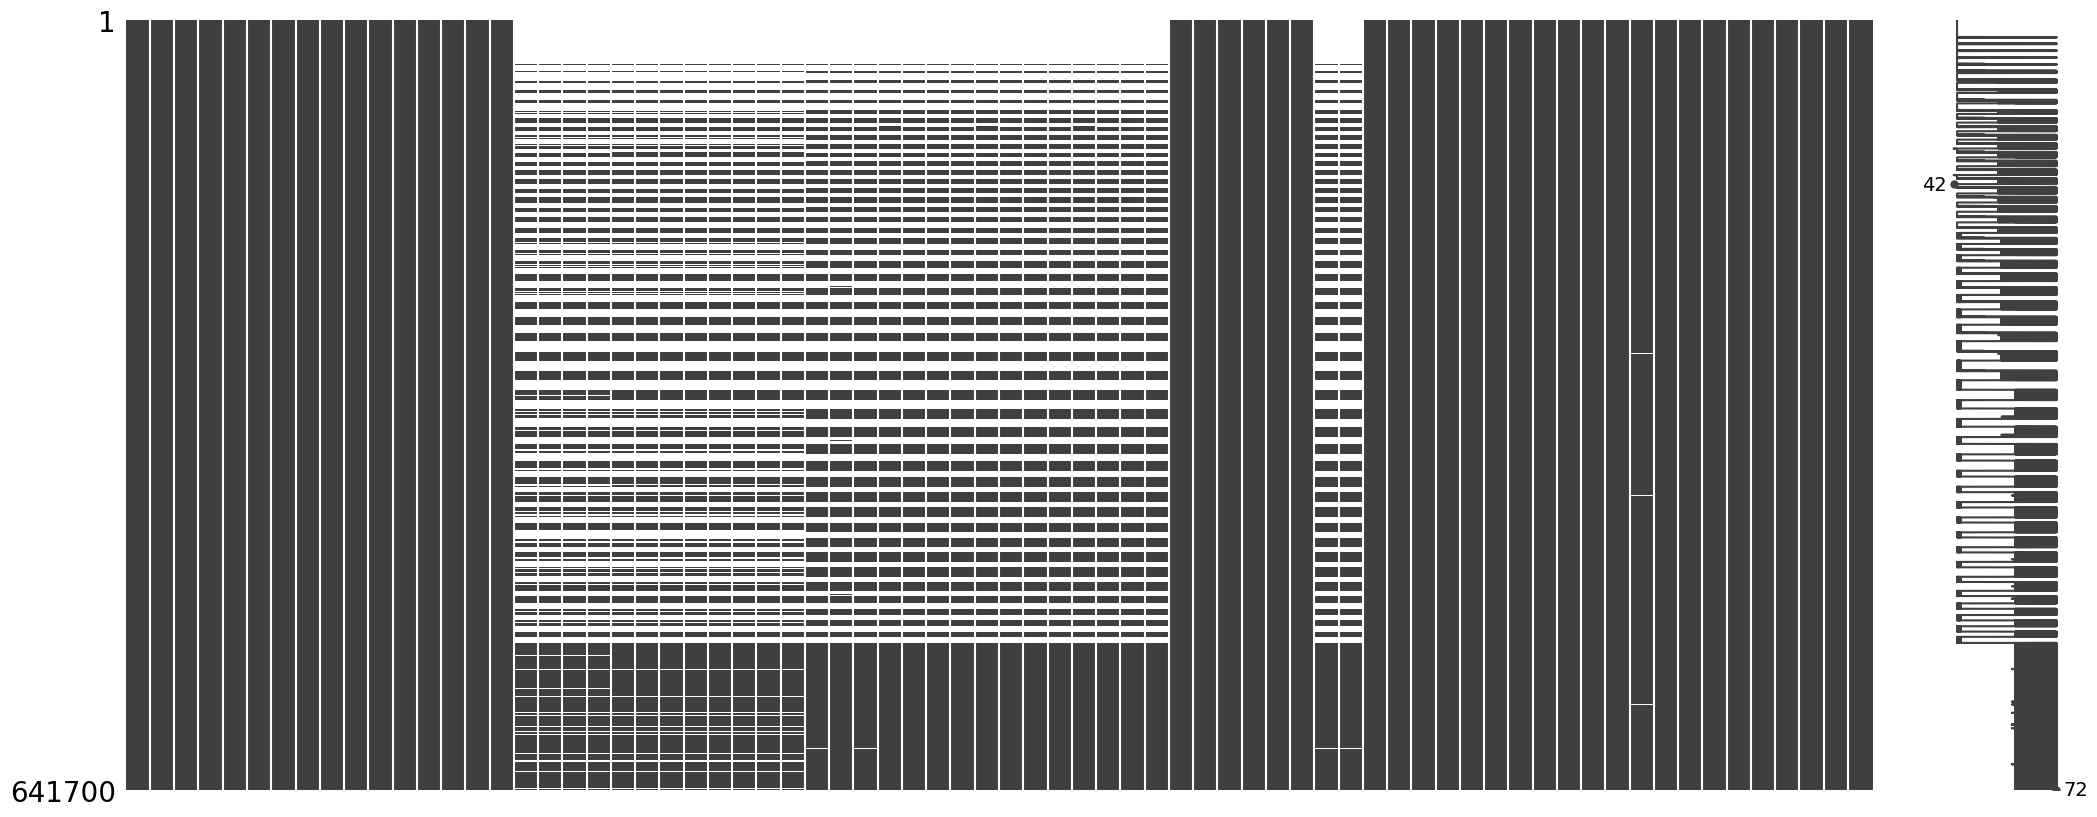

In [76]:
missingno.matrix(merged)

In [77]:
gc.collect()

6

In [78]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'lst_min', 'lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)
imputed_columns = ['lst_min', 'lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

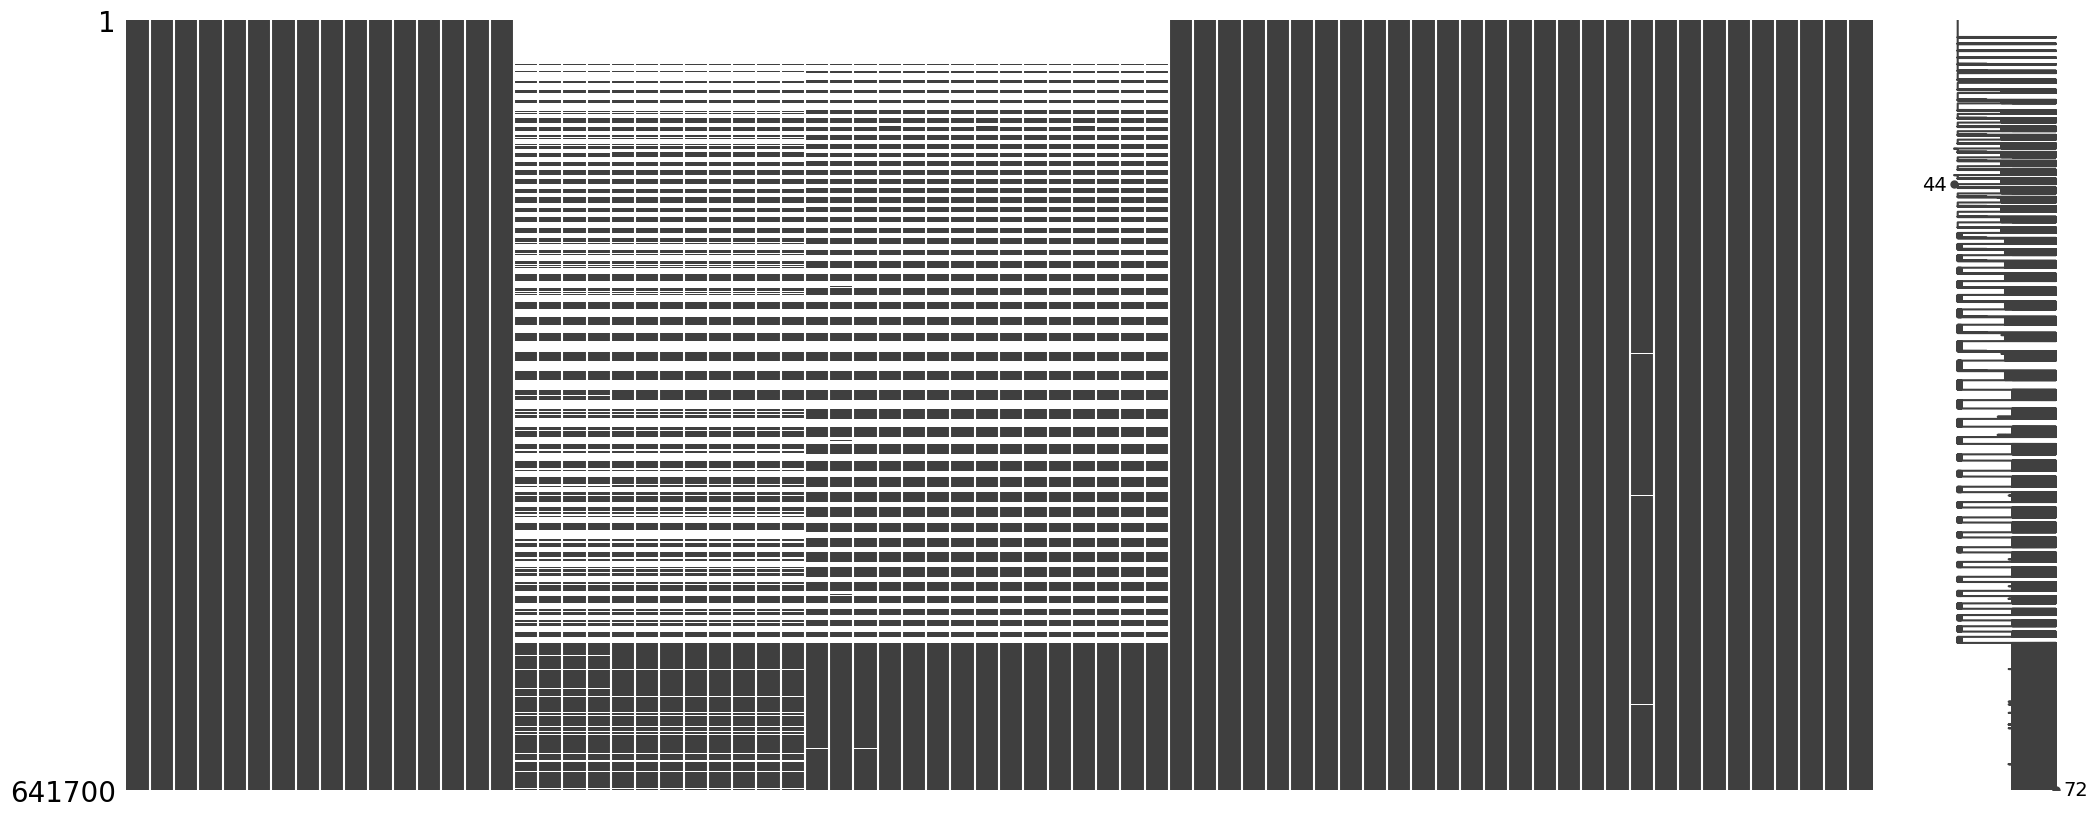

In [79]:
missingno.matrix(merged)

In [80]:
years = merged.year.unique()
years

array([2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019,
       2020, 2021, 2022, 2023])

In [81]:
cell_codes_un = merged.cell_number.unique()
cell_codes_un

array([   0,    1,    2, ..., 3562, 3563, 3564], dtype=int64)

In [82]:
rows = []
for year in years:
    for cell in cell_codes_un:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['cell_number'] == cell)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['rainfall_acc'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'cell_number': cell, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [83]:
biovars_df.head(20)

,cell_number,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,2009,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,3,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,5,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,6,2009,16.333333,18.333333,42.635659,797.534078,39.000000,-4.000000,43.000000,6.833333,6.833333,26.000000,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,7,2009,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,8,2009,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,9,2009,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [84]:
merged = pd.merge(merged, biovars_df,  how='left', on=['cell_number', 'year'])

In [85]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2017) & (merged['cell_number'] == 0)]

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
96,0,2017-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2017,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.094000,11.486000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,84,30,84.000000,30,84,10,10,1,6,6,2,0,16.791667,18.750000,41.666667,842.738591,41.000000,-4.000000,45.000000,8.000000,8.000000,27.333333,6.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
97,0,2017-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2017,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.130000,17.534000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,84,30,84.000000,30,84,10,10,1,6,6,2,0,16.791667,18.750000,41.666667,842.738591,41.000000,-4.000000,45.000000,8.000000,8.000000,27.333333,6.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
98,0,2017-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2017,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.958000,22.702000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,84,30,84.000000,30,84,10,10,1,6,6,2,0,16.791667,18.750000,41.666667,842.738591,41.000000,-4.000000,45.000000,8.000000,8.000000,27.333333,6.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
99,0,2017-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2017,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.442000,25.774000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,84,30,84.000000,30,84,10,10,1,6,6,2,0,16.791667,18.750000,41.666667,842.738591,41.000000,-4.000000,45.000000,8.000000,8.000000,27.333333,6.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
100,0,2017-05,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2017,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.090000,29.514000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,84,30,84.000000,30,84,10,10,1,6,6,2,0,16.791667,18.750000,41.666667,842.738591,41.000000,-4.000000,45.000000,8.000000,8.000000,27.333333,6.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
101,0,2017-06,EL6,κεντρικη ελλαδα,EL65,πελ

In [86]:
df_demographics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [87]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [88]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [89]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1659,EL653,2018,16571.000000,78553.000000,29971.000000,125095.000000,16256.000000,75115.000000,32718.000000,124089.000000
1660,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1661,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1662,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000


In [90]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

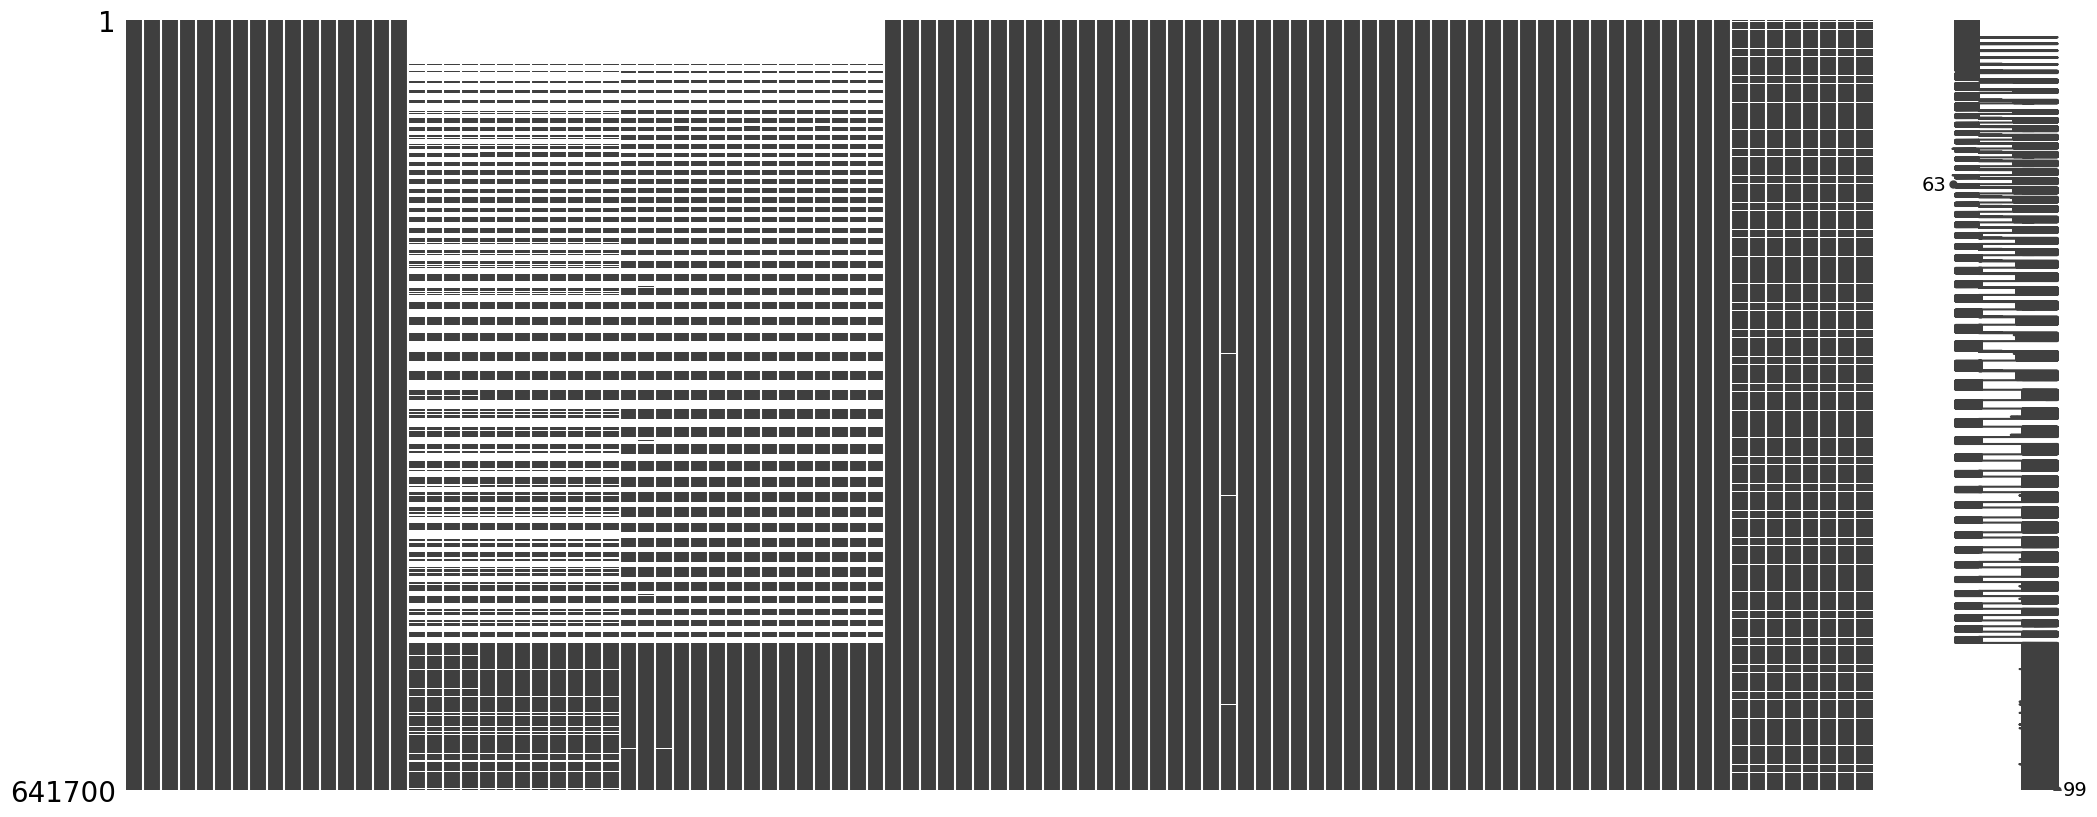

In [91]:
missingno.matrix(dataset)

In [92]:
df_economics = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [93]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [94]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [95]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.350000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1087,EL653,2016,3040.690000
1088,EL653,2017,3112.330000
1089,EL653,2018,3111.770000
1090,EL653,2019,3210.420000


In [96]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

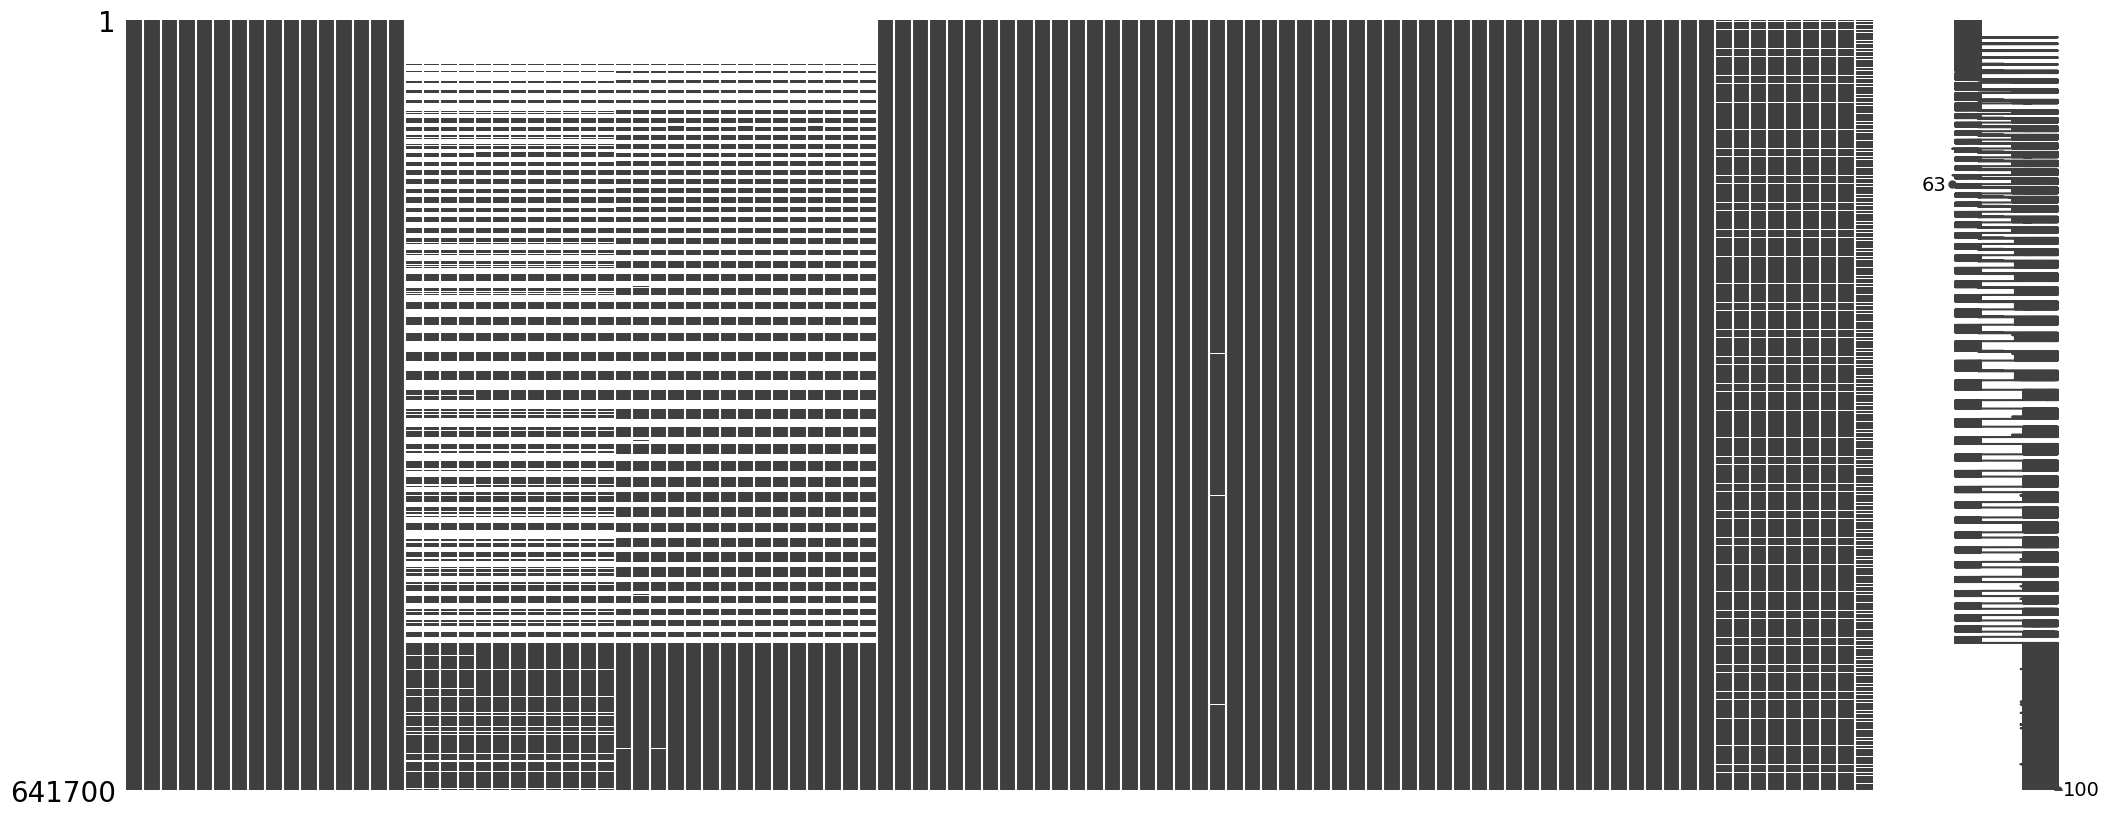

In [97]:
missingno.matrix(dataset)

In [98]:
df_trade = pd.read_csv(r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\GR_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [99]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [100]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [101]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
714,EL653,2017,3065.000000,3506.000000
715,EL653,2018,2358.000000,2885.000000
716,EL653,2019,2914.000000,3549.000000
717,EL653,2020,4062.000000,4514.000000


In [102]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

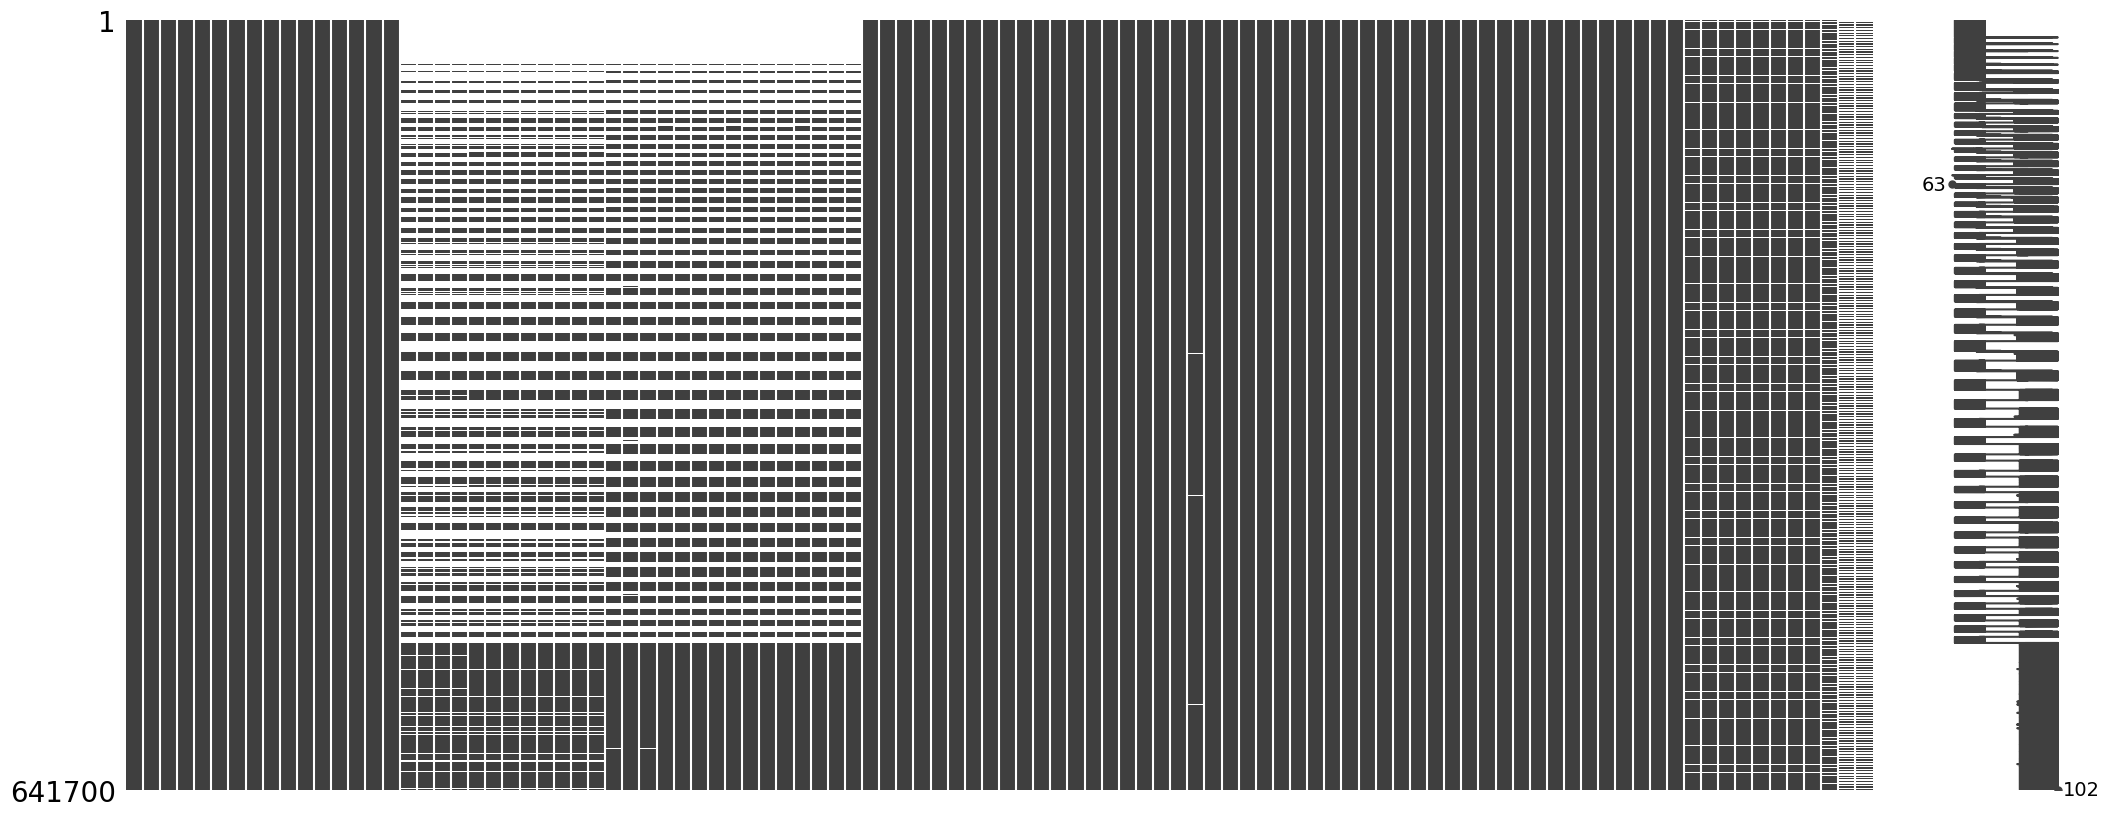

In [103]:
missingno.matrix(dataset)

In [104]:
missing = describe_dataframe(dataset, remove_zeros=True)

In [105]:
missing

,Column,Missing
16,ndvi,49.568200
17,ndmi,49.568300
18,ndwi,49.568200
19,ndbi,49.568300
20,ndvi_mean,48.676300
21,ndmi_mean,48.676300
22,ndwi_mean,48.676300
23,ndbi_mean,48.676300
24,ndvi_std,48.676300
25,ndmi_std,48.676300


In [106]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.026000,14.962000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.234000,13.066000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.530000,18.378000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.046000,24.998000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοπονν

In [107]:
dataset.reset_index(inplace=True, drop=True)

In [108]:
# dataset['cases'].value_counts()

In [109]:
# dataset['cases'].sum()

In [110]:
dataset

,cell_number,dt_placement,NUTS1_ID,NUTS1_NAME,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,LAU1_NAME,x,y,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,rainfall_acc,lst_min,lst_max,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,0,2009-01,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.026000,14.962000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
1,0,2009-02,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.234000,13.066000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
2,0,2009-03,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.530000,18.378000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
3,0,2009-04,EL6,κεντρικη ελλαδα,EL65,πελοποννησος,EL653,"λακωνια, μεσσηνια",τριφυλιας,21.594940,37.065630,2,3,1,2009,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.046000,24.998000,1440.762968,3156.780712,4,222.648703,56.699802,186.535855,0.000000,7.495073,31,94,30,94.000000,30,94,10,10,1,6,6,2,0,16.375000,18.750000,42.613636,810.197787,40.000000,-4.000000,44.000000,6.833333,6.833333,26.333333,6.833333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17313.000000,82233.000000,27717.000000,127263.000000,16712.000000,76246.000000,32321.000000,125279.000000,3836.480000,NaN,NaN
4,0,2009-05,EL6,κεντρικη ελλαδα,EL65,πελοπονν

In [111]:
cols = dataset.columns

In [112]:
print(cols)


Index(['cell_number', 'dt_placement', 'NUTS1_ID', 'NUTS1_NAME', 'NUTS2_ID',
       'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'LAU1_NAME', 'x',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=102)


In [113]:
len(cols)

102

In [114]:
years = dataset.year.unique().tolist()

In [115]:
for item in years:
    dataset[dataset.year == item].to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_GRID_{item}.csv", encoding = enc, index = False)